# Notebook 02: GDELT Collection via BigQuery

## Project 8: Digital Trace Data Collection for Conflict Research

### Overview

In this notebook, I collect conflict event data from the GDELT (Global Database of Events, Language, and Tone) project using Google BigQuery. GDELT monitors news media worldwide and codes events using the CAMEO (Conflict and Mediation Event Observations) taxonomy. GDELT 2.0 updates every 15 minutes, processing news from 65 languages.

GDELT data lives in Google BigQuery as a public dataset. I query it using SQL through the BigQuery Python client, filter to Ethiopia during the Tigray conflict period (November 2020 to November 2022), and focus on conflict-relevant event codes.

**Why GDELT matters for conflict research:** GDELT captures the media attention side of conflict. The UCDP and ACLED datasets I used in earlier projects record actual violence events. GDELT records what the media reports about. Comparing the two reveals where media coverage tracks violence intensity and where reporting gaps appear, such as during communications blackouts.

**Why GDELT is messy:** GDELT is automated and large-scale, which means significant noise. Events are duplicated across sources, geolocations are approximate, and many coded events are irrelevant to armed conflict. A major part of this notebook is data quality assessment and cleaning. Documenting the noise is a feature of the analysis, not a failure.

**What I learn here:**
- How to authenticate and query Google BigQuery from Python
- How to write SQL queries to filter large public datasets
- How to work with the CAMEO event coding taxonomy
- How to assess and document data quality issues in automated datasets
- How to clean noisy event data for analytical use

## 1. Setup and Authentication

I start by importing libraries and authenticating with Google BigQuery. The authentication uses a service account key file stored in the `credentials/` directory. This file is excluded from git via `.gitignore` to prevent accidentally pushing credentials to GitHub.

The `GOOGLE_APPLICATION_CREDENTIALS` environment variable tells the BigQuery client where to find the key file. Once set, the client handles authentication automatically.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from datetime import datetime
import warnings
warnings.filterwarnings('ignore', message='BigQuery Storage module not found')

# Set working directory
os.chdir('/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-data-collection')

# Authenticate with BigQuery using service account key
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = 'credentials/bigquery-key.json'

# Initialize the BigQuery client
client = bigquery.Client()

print(f'Working directory: {os.getcwd()}')
print(f'BigQuery client initialized')
print(f'Project: {client.project}')

Working directory: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-data-collection
BigQuery client initialized
Project: model-creek-372706


## 2. Understanding CAMEO Event Codes

GDELT codes every event using the CAMEO (Conflict and Mediation Event Observations) taxonomy. CAMEO organizes events into 20 top-level categories. For conflict research, I focus on categories that capture conflict-related behavior:

- **14x: Protest** (demonstrations, strikes, boycotts)
- **17x: Coerce** (threats, sanctions, economic pressure)
- **18x: Assault** (physical assaults, sexual violence, torture)
- **19x: Fight** (armed clashes, artillery, air strikes)
- **20x: Use unconventional mass violence** (mass killings, ethnic cleansing, chemical weapons)

I also collect some cooperation-related codes for context, since the Tigray conflict period includes ceasefire negotiations:

- **03x: Express intent to cooperate** (peace talks, negotiations)
- **05x: Diplomatic cooperation** (agreements, treaties)

The Goldstein Scale assigns a numeric score to each event code ranging from -10 (most conflictual) to +10 (most cooperative). This provides a continuous measure of conflict intensity.

I define these code ranges here so I filter consistently throughout the notebook.

In [2]:
# CAMEO event code ranges for conflict-related events
CONFLICT_CODES = {
    'protest': (140, 149),
    'coerce': (170, 179),
    'assault': (180, 189),
    'fight': (190, 199),
    'mass_violence': (200, 209)
}

# Cooperation codes for context
COOPERATION_CODES = {
    'intent_cooperate': (30, 39),
    'diplomatic_coop': (50, 59)
}

# Build a flat list of all conflict code prefixes for SQL
conflict_code_prefixes = ['14', '17', '18', '19', '20']

print('Conflict-relevant CAMEO code ranges:')
for name, (start, end) in CONFLICT_CODES.items():
    print(f'  {name}: {start}-{end}')
print()
print('Cooperation CAMEO code ranges (for context):')
for name, (start, end) in COOPERATION_CODES.items():
    print(f'  {name}: {start}-{end}')

Conflict-relevant CAMEO code ranges:
  protest: 140-149
  coerce: 170-179
  assault: 180-189
  fight: 190-199
  mass_violence: 200-209

Cooperation CAMEO code ranges (for context):
  intent_cooperate: 30-39
  diplomatic_coop: 50-59


## 3. Exploring the GDELT Events Table Schema

Before writing the main collection query, I examine the GDELT events table structure. This helps me understand what columns are available and how to filter them. The `gdelt-bq.gdeltv2.events` table contains one row per coded event, with columns for date, actor information, event codes, geographic location, and media metrics.

In [3]:
# Check table schema
table = client.get_table('gdelt-bq.gdeltv2.events')

print(f'Table: gdelt-bq.gdeltv2.events')
print(f'Total rows: {table.num_rows:,}')
print(f'Size: {table.num_bytes / 1e9:.1f} GB')
print(f'\nSchema ({len(table.schema)} columns):')
print()

# Show key columns for our analysis
key_columns = [
    'SQLDATE', 'EventCode', 'EventBaseCode', 'EventRootCode',
    'Actor1Name', 'Actor1CountryCode', 'Actor2Name', 'Actor2CountryCode',
    'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
    'GoldsteinScale', 'ActionGeo_CountryCode', 'ActionGeo_Lat', 'ActionGeo_Long',
    'SOURCEURL'
]

for field in table.schema:
    marker = ' <-- key' if field.name in key_columns else ''
    if marker:
        print(f'  {field.name} ({field.field_type}){marker}')

Table: gdelt-bq.gdeltv2.events
Total rows: 884,751,340
Size: 383.6 GB

Schema (61 columns):

  SQLDATE (INTEGER) <-- key
  Actor1Name (STRING) <-- key
  Actor1CountryCode (STRING) <-- key
  Actor2Name (STRING) <-- key
  Actor2CountryCode (STRING) <-- key
  EventCode (STRING) <-- key
  EventBaseCode (STRING) <-- key
  EventRootCode (STRING) <-- key
  GoldsteinScale (FLOAT) <-- key
  NumMentions (INTEGER) <-- key
  NumSources (INTEGER) <-- key
  NumArticles (INTEGER) <-- key
  AvgTone (FLOAT) <-- key
  ActionGeo_CountryCode (STRING) <-- key
  ActionGeo_Lat (FLOAT) <-- key
  ActionGeo_Long (FLOAT) <-- key
  SOURCEURL (STRING) <-- key


## 4. Scoping the Data: How Many Events?

Before downloading all the data, I run a count query to understand the volume. This is a BigQuery best practice: scoping queries are cheap and fast, while downloading unnecessary data wastes your free tier quota.

I check three counts:
1. All GDELT events geolocated to Ethiopia in the study period
2. Only conflict-relevant events (CAMEO codes starting with 14, 17, 18, 19, 20)
3. Monthly distribution to see if volumes are manageable

In [4]:
# Count all Ethiopia events in the study period
count_query = """
SELECT 
    COUNT(*) as total_events,
    COUNT(DISTINCT SOURCEURL) as unique_sources,
    MIN(SQLDATE) as first_date,
    MAX(SQLDATE) as last_date
FROM `gdelt-bq.gdeltv2.events`
WHERE ActionGeo_CountryCode = 'ET'
AND CAST(SQLDATE AS STRING) BETWEEN '20201101' AND '20221130'
"""

counts = client.query(count_query).to_dataframe()
print('All Ethiopia events (Nov 2020 - Nov 2022):')
print(counts.to_string(index=False))
print()

# Count conflict-relevant events only
conflict_count_query = """
SELECT 
    COUNT(*) as conflict_events,
    COUNT(DISTINCT SOURCEURL) as unique_sources
FROM `gdelt-bq.gdeltv2.events`
WHERE ActionGeo_CountryCode = 'ET'
AND CAST(SQLDATE AS STRING) BETWEEN '20201101' AND '20221130'
AND (
    EventRootCode = '14' OR
    EventRootCode = '17' OR
    EventRootCode = '18' OR
    EventRootCode = '19' OR
    EventRootCode = '20'
)
"""

conflict_counts = client.query(conflict_count_query).to_dataframe()
print('Conflict-relevant events only:')
print(conflict_counts.to_string(index=False))

All Ethiopia events (Nov 2020 - Nov 2022):
 total_events  unique_sources  first_date  last_date
       332825           84675    20201101   20221130

Conflict-relevant events only:
 conflict_events  unique_sources
           57971           23203


## 5. Monthly Event Distribution (Pre-Download Check)

I check the monthly distribution before downloading the full dataset. This confirms the data volume is manageable and gives a first look at temporal patterns.

In [5]:
# Monthly counts by conflict type
monthly_query = """
SELECT 
    SUBSTR(CAST(SQLDATE AS STRING), 1, 6) as year_month,
    EventRootCode,
    COUNT(*) as event_count
FROM `gdelt-bq.gdeltv2.events`
WHERE ActionGeo_CountryCode = 'ET'
AND CAST(SQLDATE AS STRING) BETWEEN '20201101' AND '20221130'
AND (
    EventRootCode = '14' OR
    EventRootCode = '17' OR
    EventRootCode = '18' OR
    EventRootCode = '19' OR
    EventRootCode = '20'
)
GROUP BY year_month, EventRootCode
ORDER BY year_month, EventRootCode
"""

monthly_dist = client.query(monthly_query).to_dataframe()

# Pivot for readable display
monthly_pivot = monthly_dist.pivot_table(
    index='year_month', columns='EventRootCode', 
    values='event_count', fill_value=0
)

# Rename columns for clarity
code_labels = {'14': 'Protest', '17': 'Coerce', '18': 'Assault', '19': 'Fight', '20': 'Mass Violence'}
monthly_pivot.columns = [code_labels.get(c, c) for c in monthly_pivot.columns]
monthly_pivot['Total'] = monthly_pivot.sum(axis=1)

print('Monthly conflict event counts by CAMEO category:')
print(monthly_pivot.to_string())
print(f'\nTotal conflict events: {monthly_pivot["Total"].sum()}')

Monthly conflict event counts by CAMEO category:
            Protest  Coerce  Assault   Fight  Mass Violence   Total
year_month                                                         
202011        184.0   844.0    517.0  4526.0          122.0  6193.0
202012        174.0   630.0    338.0  2835.0           93.0  4070.0
202101        137.0   390.0    204.0  1377.0           38.0  2146.0
202102        166.0   365.0    275.0  1263.0           72.0  2141.0
202103        198.0   378.0    345.0  1372.0          250.0  2543.0
202104        144.0   284.0    223.0  1271.0          182.0  2104.0
202105        198.0   377.0    285.0  1160.0          178.0  2198.0
202106        314.0   419.0    315.0  1833.0          100.0  2981.0
202107        210.0   507.0    211.0  2045.0           87.0  3060.0
202108        108.0   209.0    189.0  1502.0           88.0  2096.0
202109        229.0   309.0    146.0  1144.0          104.0  1932.0
202110        141.0   400.0    276.0  2726.0           41.0  3584.0

## 6. Main Data Collection Query

Now I download the full conflict-relevant event data. The query retrieves all events geolocated to Ethiopia during the study period where the event type falls in one of the five conflict CAMEO categories.

I select columns in four groups:
1. **Temporal:** SQLDATE, MonthYear for time series analysis
2. **Event coding:** EventCode, EventBaseCode, EventRootCode, GoldsteinScale, QuadClass for classifying the event type and intensity
3. **Actors:** Actor1Name, Actor1CountryCode, Actor2Name, Actor2CountryCode for identifying who is involved
4. **Media metrics:** NumMentions, NumSources, NumArticles, AvgTone for measuring media attention and framing
5. **Geography:** ActionGeo_Lat, ActionGeo_Long, ActionGeo_FullName for spatial analysis
6. **Source:** SOURCEURL for deduplication and traceability

In [6]:
# Main collection query: all conflict events for Ethiopia
main_query = """
SELECT 
    SQLDATE,
    MonthYear,
    EventCode,
    EventBaseCode,
    EventRootCode,
    QuadClass,
    GoldsteinScale,
    NumMentions,
    NumSources,
    NumArticles,
    AvgTone,
    Actor1Name,
    Actor1CountryCode,
    Actor1Type1Code,
    Actor2Name,
    Actor2CountryCode,
    Actor2Type1Code,
    ActionGeo_FullName,
    ActionGeo_CountryCode,
    ActionGeo_Lat,
    ActionGeo_Long,
    SOURCEURL
FROM `gdelt-bq.gdeltv2.events`
WHERE ActionGeo_CountryCode = 'ET'
AND CAST(SQLDATE AS STRING) BETWEEN '20201101' AND '20221130'
AND (
    EventRootCode = '14' OR
    EventRootCode = '17' OR
    EventRootCode = '18' OR
    EventRootCode = '19' OR
    EventRootCode = '20'
)
ORDER BY SQLDATE ASC
"""

print('Executing main collection query...')
print('This queries the full GDELT events table. It takes 15-60 seconds.')
print()

df_raw = client.query(main_query).to_dataframe()

print(f'Collection complete!')
print(f'Rows retrieved: {len(df_raw):,}')
print(f'Columns: {df_raw.shape[1]}')
print(f'\nDate range: {df_raw["SQLDATE"].min()} to {df_raw["SQLDATE"].max()}')

Executing main collection query...
This queries the full GDELT events table. It takes 15-60 seconds.

Collection complete!
Rows retrieved: 57,971
Columns: 22

Date range: 20201101 to 20221130


## 7. Save Raw Data

I save the raw query results immediately, before any cleaning. This follows the same principle from Notebook 01: if cleaning goes wrong, I reload from the raw file instead of re-running the BigQuery query (which uses free tier quota).

In [7]:
# Save raw data
df_raw.to_csv('data/raw/gdelt_raw.csv', index=False, encoding='utf-8')

file_size = os.path.getsize('data/raw/gdelt_raw.csv') / (1024 * 1024)
print(f'Raw data saved: data/raw/gdelt_raw.csv')
print(f'File size: {file_size:.1f} MB')
print(f'Rows: {len(df_raw):,}')

Raw data saved: data/raw/gdelt_raw.csv
File size: 12.1 MB
Rows: 57,971


## 8. Initial Data Exploration

I examine the raw data to understand its structure before cleaning. This step reveals the types of quality issues I need to address.

In [8]:
# Basic info
print('=== DataFrame Info ===')
print(f'Shape: {df_raw.shape}')
print()

print('=== Column Types ===')
print(df_raw.dtypes)
print()

print('=== Missing Values ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
print(missing_df[missing_df['count'] > 0].sort_values('count', ascending=False))
print()

print('=== First 5 Rows ===')
print(df_raw.head())

=== DataFrame Info ===
Shape: (57971, 22)

=== Column Types ===
SQLDATE                    Int64
MonthYear                  Int64
EventCode                 object
EventBaseCode             object
EventRootCode             object
QuadClass                  Int64
GoldsteinScale           float64
NumMentions                Int64
NumSources                 Int64
NumArticles                Int64
AvgTone                  float64
Actor1Name                object
Actor1CountryCode         object
Actor1Type1Code           object
Actor2Name                object
Actor2CountryCode         object
Actor2Type1Code           object
ActionGeo_FullName        object
ActionGeo_CountryCode     object
ActionGeo_Lat            float64
ActionGeo_Long           float64
SOURCEURL                 object
dtype: object

=== Missing Values ===
                   count  percent
Actor2Type1Code    35206     60.7
Actor2CountryCode  34328     59.2
Actor1Type1Code    29381     50.7
Actor1CountryCode  28124     48.5
Ac

## 9. Event Type Distribution

I break down the events by CAMEO root code to see which conflict types dominate. The `QuadClass` column provides another view: GDELT classifies events into four quadrants (Verbal Cooperation, Material Cooperation, Verbal Conflict, Material Conflict). For conflict research, I care most about Material Conflict (QuadClass = 4), which represents physical actions rather than statements.

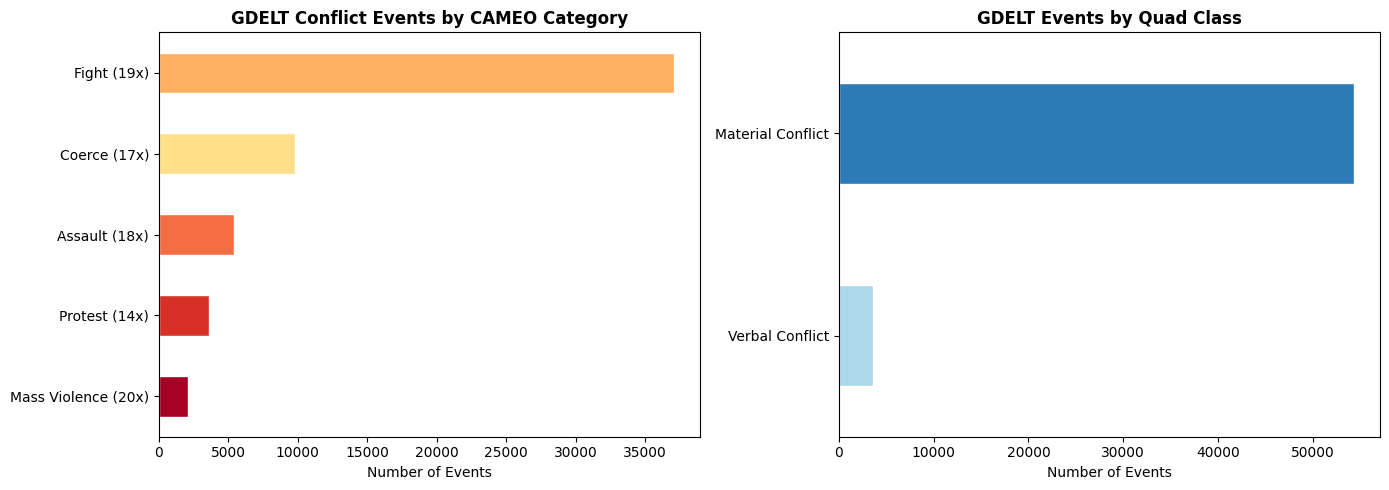


Event category breakdown:
  Fight (19x): 37,087 (64.0%)
  Coerce (17x): 9,813 (16.9%)
  Assault (18x): 5,402 (9.3%)
  Protest (14x): 3,602 (6.2%)
  Mass Violence (20x): 2,067 (3.6%)


In [9]:
# Distribution by EventRootCode
root_code_labels = {
    '14': 'Protest (14x)',
    '17': 'Coerce (17x)',
    '18': 'Assault (18x)',
    '19': 'Fight (19x)',
    '20': 'Mass Violence (20x)'
}

df_raw['event_category'] = df_raw['EventRootCode'].map(root_code_labels)

category_counts = df_raw['event_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of event categories
colors = ['#fdae61', '#fee08b', '#f46d43', '#d73027', '#a50026']
category_counts.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('GDELT Conflict Events by CAMEO Category', fontweight='bold')
axes[0].set_xlabel('Number of Events')
axes[0].set_ylabel('')
axes[0].invert_yaxis()

# QuadClass distribution
quad_labels = {1: 'Verbal Coop', 2: 'Material Coop', 3: 'Verbal Conflict', 4: 'Material Conflict'}
df_raw['quad_label'] = df_raw['QuadClass'].map(quad_labels)
quad_counts = df_raw['quad_label'].value_counts()
quad_counts.plot(kind='barh', ax=axes[1], color=['#2c7bb6', '#abd9e9', '#fdae61', '#d73027'], edgecolor='white')
axes[1].set_title('GDELT Events by Quad Class', fontweight='bold')
axes[1].set_xlabel('Number of Events')
axes[1].set_ylabel('')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('figures/gdelt_event_types.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEvent category breakdown:')
for cat, count in category_counts.items():
    print(f'  {cat}: {count:,} ({count/len(df_raw)*100:.1f}%)')

## 10. Data Quality Assessment

Data quality assessment is one of the most important outputs of this notebook. GDELT's automated coding produces known quality issues that I need to document and address:

1. **Duplicate events:** The same real-world event reported by multiple news sources creates multiple GDELT rows. I identify duplicates using the SOURCEURL field.
2. **Missing geolocation:** Some events lack latitude/longitude coordinates. These are less useful for spatial analysis.
3. **Low-confidence events:** Events mentioned in only one source (NumMentions = 1) are less reliable than events covered by multiple sources.
4. **Missing actor information:** Some events have no identified actors, making them harder to interpret.

I quantify each issue so the quality assessment is specific, not vague.

In [10]:
print('=' * 60)
print('DATA QUALITY ASSESSMENT')
print('=' * 60)
print()

# 1. Duplicate SOURCEURLs
total = len(df_raw)
unique_urls = df_raw['SOURCEURL'].nunique()
null_urls = df_raw['SOURCEURL'].isnull().sum()
dup_urls = total - unique_urls - null_urls
print(f'1. SOURCE URL DUPLICATES')
print(f'   Total events: {total:,}')
print(f'   Unique source URLs: {unique_urls:,}')
print(f'   Missing URLs: {null_urls:,}')
print(f'   Duplicate URLs: {dup_urls:,} ({dup_urls/total*100:.1f}%)')
print()

# 2. Missing geolocation
missing_geo = df_raw['ActionGeo_Lat'].isnull().sum()
print(f'2. MISSING GEOLOCATION')
print(f'   Events without lat/long: {missing_geo:,} ({missing_geo/total*100:.1f}%)')
print()

# 3. Low-confidence events (single mention)
single_mention = (df_raw['NumMentions'] == 1).sum()
print(f'3. LOW-CONFIDENCE EVENTS (single mention)')
print(f'   Events with NumMentions = 1: {single_mention:,} ({single_mention/total*100:.1f}%)')
print()

# 4. Missing actor info
missing_actor1 = df_raw['Actor1Name'].isnull().sum()
missing_actor2 = df_raw['Actor2Name'].isnull().sum()
missing_both = ((df_raw['Actor1Name'].isnull()) & (df_raw['Actor2Name'].isnull())).sum()
print(f'4. MISSING ACTOR INFORMATION')
print(f'   Missing Actor1: {missing_actor1:,} ({missing_actor1/total*100:.1f}%)')
print(f'   Missing Actor2: {missing_actor2:,} ({missing_actor2/total*100:.1f}%)')
print(f'   Missing both actors: {missing_both:,} ({missing_both/total*100:.1f}%)')
print()

# 5. NumMentions distribution
print(f'5. MEDIA ATTENTION DISTRIBUTION (NumMentions)')
print(f'   {df_raw["NumMentions"].describe().to_string()}')

DATA QUALITY ASSESSMENT

1. SOURCE URL DUPLICATES
   Total events: 57,971
   Unique source URLs: 23,203
   Missing URLs: 0
   Duplicate URLs: 34,768 (60.0%)

2. MISSING GEOLOCATION
   Events without lat/long: 0 (0.0%)

3. LOW-CONFIDENCE EVENTS (single mention)
   Events with NumMentions = 1: 7,610 (13.1%)

4. MISSING ACTOR INFORMATION
   Missing Actor1: 4,187 (7.2%)
   Missing Actor2: 13,632 (23.5%)
   Missing both actors: 0 (0.0%)

5. MEDIA ATTENTION DISTRIBUTION (NumMentions)
   count     57971.0
mean     5.249038
std      4.318611
min           1.0
25%           2.0
50%           4.0
75%           8.0
max          90.0


## 11. Data Cleaning

Based on the quality assessment, I apply the following cleaning steps:

1. **Remove exact URL duplicates:** When the same SOURCEURL appears multiple times with the same EventCode and date, I keep only the first occurrence. This removes cases where the same article generated multiple identical event codings.
2. **Flag low-confidence events:** I add a column flagging events with only 1 mention. I do not remove them because they still carry information, but analyses should weight them differently.
3. **Parse dates:** I convert the SQLDATE integer (e.g., 20201104) into a proper datetime column and create a year-month column for time series.
4. **Categorize events:** I add readable labels for event categories.

I do not remove events with missing actors or geolocation. Missing data is common in GDELT and removing all of it would lose too much information. Instead, I flag these cases for awareness.

In [11]:
# Start cleaning
df = df_raw.copy()
print(f'Starting rows: {len(df):,}')

# 1. Remove duplicate rows based on SOURCEURL + EventCode + SQLDATE
before_dedup = len(df)
df = df.drop_duplicates(subset=['SOURCEURL', 'EventCode', 'SQLDATE'], keep='first')
removed = before_dedup - len(df)
print(f'Removed {removed:,} URL/code/date duplicates ({removed/before_dedup*100:.1f}%)')

# 2. Flag low-confidence events
df['low_confidence'] = df['NumMentions'] == 1
print(f'Flagged {df["low_confidence"].sum():,} low-confidence events (single mention)')

# 3. Parse dates
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d', errors='coerce')
df['year_month'] = df['date'].dt.to_period('M')

# 4. Add readable event category labels
df['event_category'] = df['EventRootCode'].map(root_code_labels)

# 5. Flag missing geolocation
df['has_geolocation'] = df['ActionGeo_Lat'].notna()

print(f'\nFinal cleaned rows: {len(df):,}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

Starting rows: 57,971
Removed 27,370 URL/code/date duplicates (47.2%)
Flagged 2,890 low-confidence events (single mention)

Final cleaned rows: 30,601
Date range: 2020-11-01 to 2022-11-30


## 12. Conflict Event Time Series

I plot the monthly time series of GDELT conflict events, broken down by CAMEO category. This is the core analytical output: it shows how media-reported conflict intensity varied over the Tigray conflict period.

I annotate key events on the timeline to connect the data patterns to real-world developments.

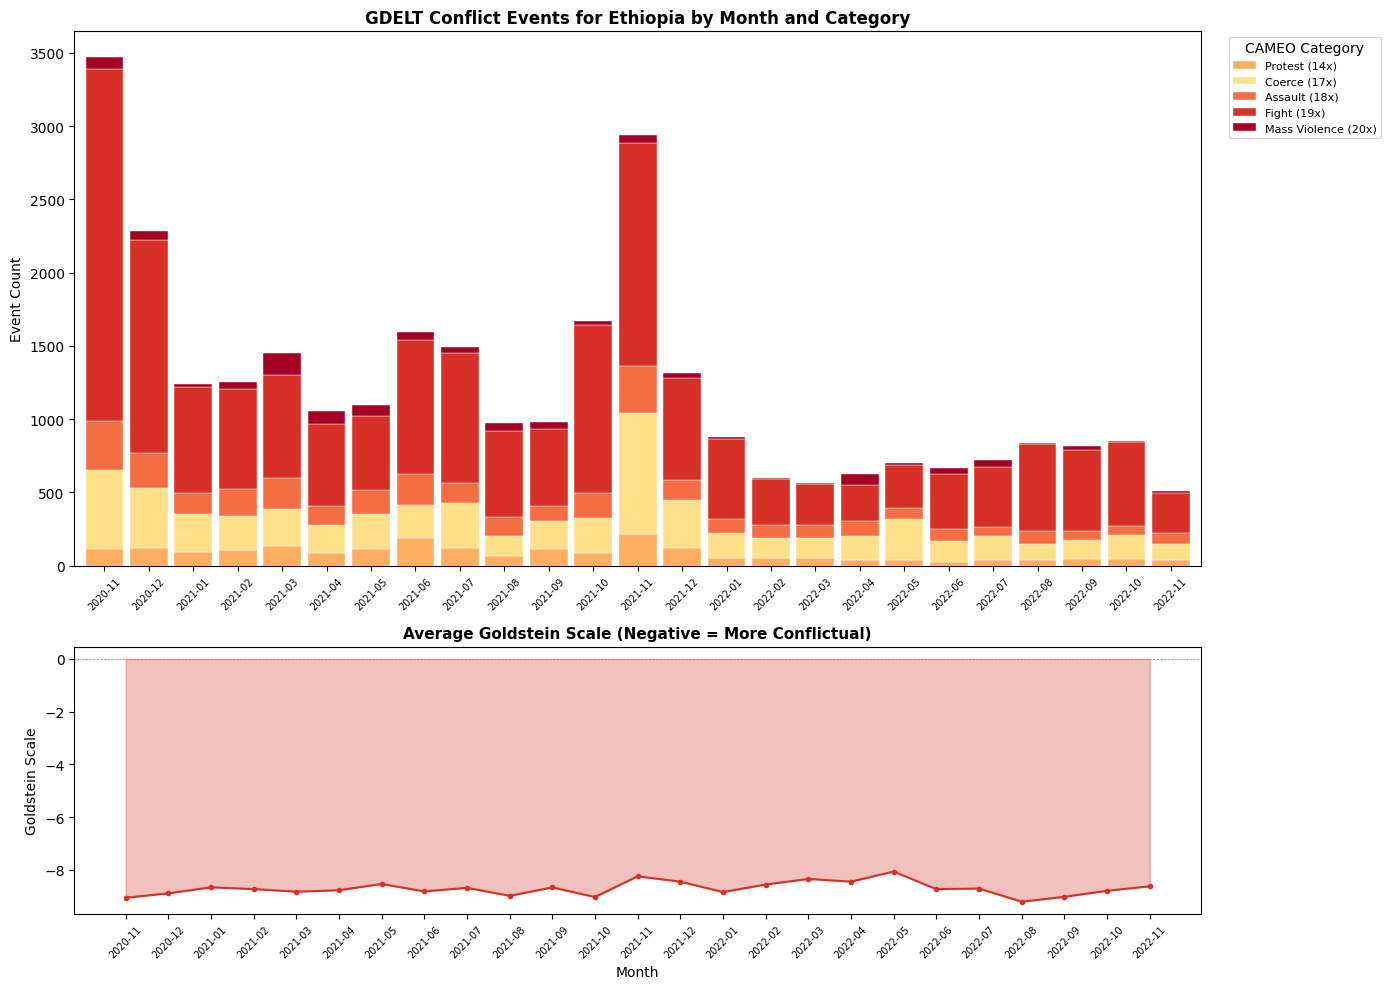

Most active month: 2020-11 (3,473 events)
Least active month: 2022-11 (510 events)
Average Goldstein Scale: -8.73


In [12]:
# Monthly counts by event category
monthly = df.groupby(['year_month', 'event_category']).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

# Total monthly counts
monthly_total = df.groupby('year_month').size()
monthly_total.index = monthly_total.index.astype(str)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# Panel 1: Stacked bar by category
colors_map = {
    'Protest (14x)': '#fdae61',
    'Coerce (17x)': '#fee08b',
    'Assault (18x)': '#f46d43',
    'Fight (19x)': '#d73027',
    'Mass Violence (20x)': '#a50026'
}

# Reorder columns
col_order = ['Protest (14x)', 'Coerce (17x)', 'Assault (18x)', 'Fight (19x)', 'Mass Violence (20x)']
plot_cols = [c for c in col_order if c in monthly.columns]
monthly[plot_cols].plot(kind='bar', stacked=True, ax=axes[0],
                        color=[colors_map[c] for c in plot_cols],
                        edgecolor='white', linewidth=0.3, width=0.85)

axes[0].set_title('GDELT Conflict Events for Ethiopia by Month and Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Event Count')
axes[0].set_xlabel('')
axes[0].legend(title='CAMEO Category', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)

# Panel 2: Average Goldstein Scale (conflict intensity)
monthly_goldstein = df.groupby('year_month')['GoldsteinScale'].mean()
monthly_goldstein.index = monthly_goldstein.index.astype(str)

axes[1].plot(range(len(monthly_goldstein)), monthly_goldstein.values, 
             color='#d73027', linewidth=1.5, marker='o', markersize=3)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[1].fill_between(range(len(monthly_goldstein)), monthly_goldstein.values, 0,
                      where=monthly_goldstein.values < 0, alpha=0.3, color='#d73027')
axes[1].fill_between(range(len(monthly_goldstein)), monthly_goldstein.values, 0,
                      where=monthly_goldstein.values > 0, alpha=0.3, color='#2c7bb6')
axes[1].set_xticks(range(len(monthly_goldstein)))
axes[1].set_xticklabels(monthly_goldstein.index, rotation=45, fontsize=7)
axes[1].set_title('Average Goldstein Scale (Negative = More Conflictual)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Goldstein Scale')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('figures/gdelt_monthly_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Most active month: {monthly_total.idxmax()} ({monthly_total.max():,} events)')
print(f'Least active month: {monthly_total.idxmin()} ({monthly_total.min():,} events)')
print(f'Average Goldstein Scale: {df["GoldsteinScale"].mean():.2f}')

## 13. Actor Analysis

I examine which actors appear most frequently in the GDELT conflict events. GDELT extracts actor names from news text, so these reflect how media names the parties involved. Actor names in GDELT are often inconsistent (e.g., "ETHIOPIA," "ETHIOPIAN," "GOVERNMENT OF ETHIOPIA" might all refer to the same actor). This is another data quality issue to document.

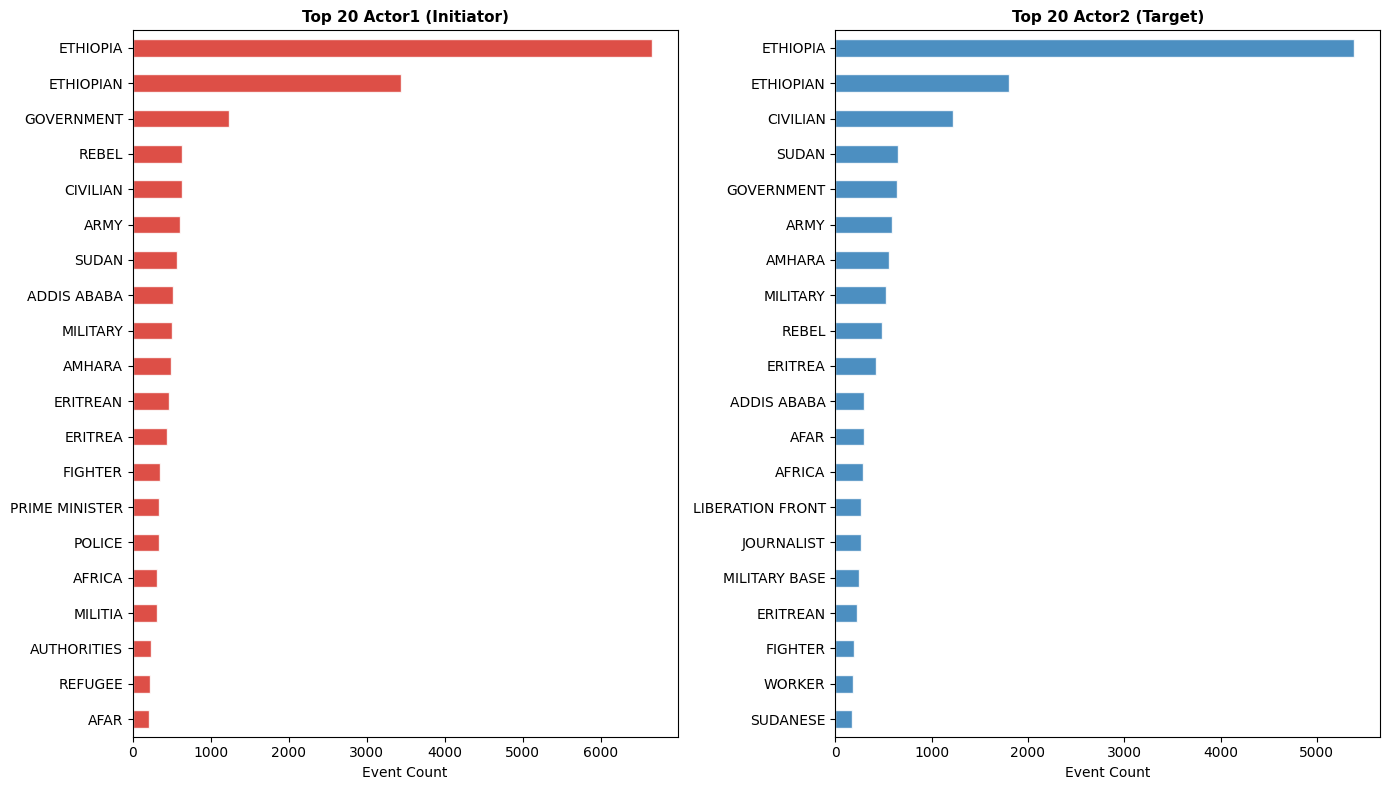

In [13]:
# Top Actor1 names (the initiator of the action)
actor1_counts = df['Actor1Name'].value_counts().head(20)

# Top Actor2 names (the target of the action)
actor2_counts = df['Actor2Name'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

actor1_counts.plot(kind='barh', ax=axes[0], color='#d73027', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 20 Actor1 (Initiator)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Event Count')
axes[0].set_ylabel('')
axes[0].invert_yaxis()

actor2_counts.plot(kind='barh', ax=axes[1], color='#2c7bb6', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 20 Actor2 (Target)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Event Count')
axes[1].set_ylabel('')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('figures/gdelt_top_actors.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Media Attention Metrics

GDELT records how much media attention each event receives through three fields: NumMentions (total mentions across all sources), NumSources (distinct sources covering the event), and NumArticles (distinct articles). I also look at AvgTone, which measures the average sentiment of media coverage on a scale from negative to positive.

These metrics are useful for the integration analysis in Notebook 04, where I compare media attention to actual violence intensity.

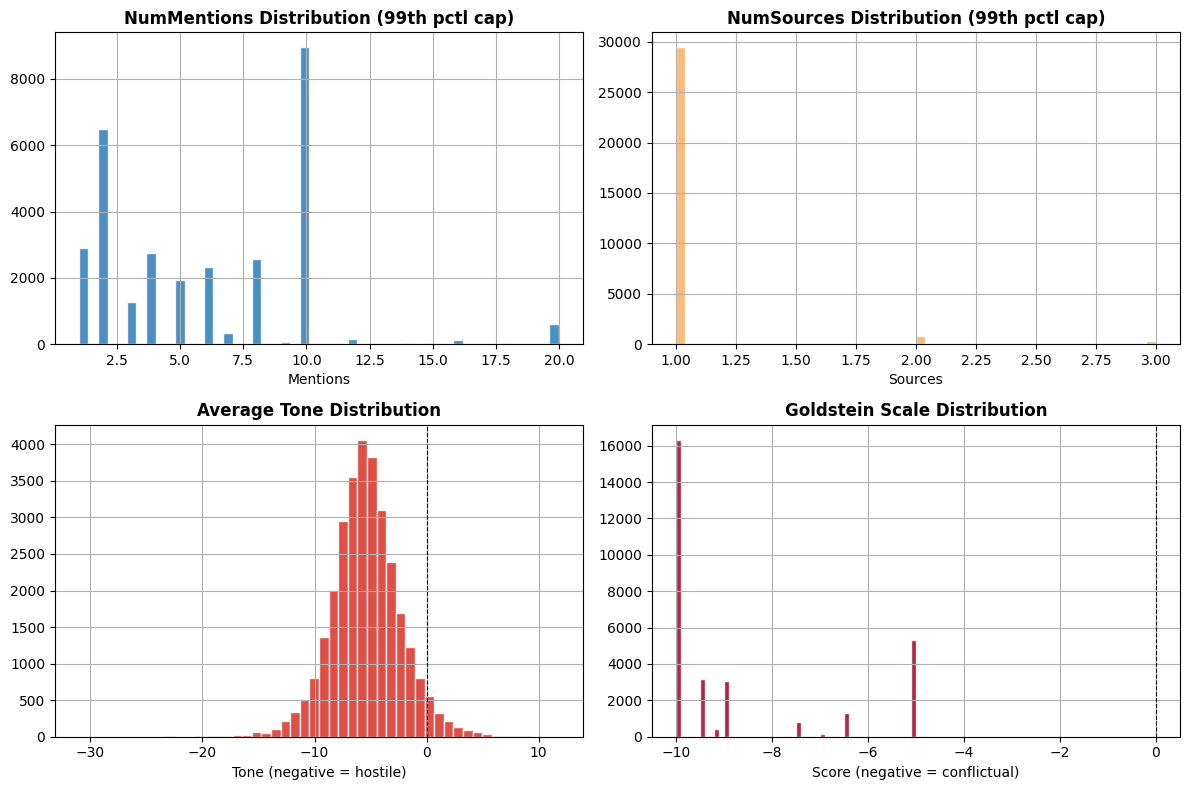

Media attention summary statistics:
       NumMentions  NumSources  NumArticles   AvgTone  GoldsteinScale
count      30601.0     30601.0      30601.0  30601.00        30601.00
mean          6.15        1.06         6.04     -5.41           -8.73
std           4.62        0.36         4.34      3.09            1.90
min            1.0         1.0          1.0    -31.03          -10.00
25%            2.0         1.0          2.0     -7.26          -10.00
50%            5.0         1.0          5.0     -5.49          -10.00
75%           10.0         1.0         10.0     -3.63           -9.00
max           90.0        14.0         80.0     11.82           -5.00


In [14]:
# Media attention distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# NumMentions (log scale because of heavy right tail)
df['NumMentions'].clip(upper=df['NumMentions'].quantile(0.99)).hist(
    bins=50, ax=axes[0, 0], color='#2c7bb6', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('NumMentions Distribution (99th pctl cap)', fontweight='bold')
axes[0, 0].set_xlabel('Mentions')

# NumSources
df['NumSources'].clip(upper=df['NumSources'].quantile(0.99)).hist(
    bins=50, ax=axes[0, 1], color='#fdae61', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('NumSources Distribution (99th pctl cap)', fontweight='bold')
axes[0, 1].set_xlabel('Sources')

# AvgTone
df['AvgTone'].hist(bins=50, ax=axes[1, 0], color='#d73027', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Average Tone Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Tone (negative = hostile)')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# GoldsteinScale
df['GoldsteinScale'].hist(bins=50, ax=axes[1, 1], color='#a50026', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Goldstein Scale Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Score (negative = conflictual)')
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('figures/gdelt_media_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Media attention summary statistics:')
print(df[['NumMentions', 'NumSources', 'NumArticles', 'AvgTone', 'GoldsteinScale']].describe().round(2))

## 15. Save Processed Data

I save the cleaned dataset and a monthly aggregation file. The monthly file will be loaded directly in Notebook 04 for the cross-source integration analysis.

In [15]:
# Save cleaned event-level data
df_save = df.copy()
df_save['date'] = df_save['date'].dt.strftime('%Y-%m-%d')
df_save['year_month'] = df_save['year_month'].astype(str)
df_save.to_csv('data/processed/gdelt_conflict_events.csv', index=False, encoding='utf-8')
print(f'Event data saved: data/processed/gdelt_conflict_events.csv ({len(df_save):,} rows)')

# Save monthly aggregation for Notebook 04
monthly_agg = df.groupby('year_month').agg(
    event_count=('SQLDATE', 'size'),
    avg_goldstein=('GoldsteinScale', 'mean'),
    avg_tone=('AvgTone', 'mean'),
    total_mentions=('NumMentions', 'sum'),
    unique_sources=('SOURCEURL', 'nunique'),
    fight_count=('EventRootCode', lambda x: (x == '19').sum()),
    assault_count=('EventRootCode', lambda x: (x == '18').sum()),
    mass_violence_count=('EventRootCode', lambda x: (x == '20').sum())
).reset_index()

monthly_agg['year_month'] = monthly_agg['year_month'].astype(str)
monthly_agg.to_csv('data/processed/gdelt_monthly_counts.csv', index=False, encoding='utf-8')
print(f'Monthly data saved: data/processed/gdelt_monthly_counts.csv ({len(monthly_agg)} rows)')

# File sizes
for fpath in ['data/processed/gdelt_conflict_events.csv', 'data/processed/gdelt_monthly_counts.csv']:
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fpath}: {size_kb:.0f} KB')

Event data saved: data/processed/gdelt_conflict_events.csv (30,601 rows)
Monthly data saved: data/processed/gdelt_monthly_counts.csv (25 rows)
  data/processed/gdelt_conflict_events.csv: 8315 KB
  data/processed/gdelt_monthly_counts.csv: 2 KB


## 16. Collection Summary

I print a final summary of the GDELT collection and quality assessment.

In [16]:
print('=' * 60)
print('GDELT COLLECTION SUMMARY')
print('=' * 60)
print(f'Source:            GDELT v2 via Google BigQuery')
print(f'Table:             gdelt-bq.gdeltv2.events')
print(f'Country filter:    ActionGeo_CountryCode = ET')
print(f'Date range:        2020-11-01 to 2022-11-30')
print(f'CAMEO filters:     14x, 17x, 18x, 19x, 20x')
print()
print(f'Raw events:        {len(df_raw):,}')
print(f'After dedup:       {len(df):,}')
print(f'Removed:           {len(df_raw) - len(df):,} duplicates')
print()
print(f'Quality flags:')
print(f'  Low-confidence (1 mention): {df["low_confidence"].sum():,} ({df["low_confidence"].mean()*100:.1f}%)')
print(f'  Missing geolocation:        {(~df["has_geolocation"]).sum():,} ({(~df["has_geolocation"]).mean()*100:.1f}%)')
print(f'  Missing Actor1:             {df["Actor1Name"].isnull().sum():,}')
print(f'  Missing Actor2:             {df["Actor2Name"].isnull().sum():,}')
print()
print('Files saved:')
print('  data/raw/gdelt_raw.csv')
print('  data/processed/gdelt_conflict_events.csv')
print('  data/processed/gdelt_monthly_counts.csv')
print('  figures/gdelt_event_types.png')
print('  figures/gdelt_monthly_timeseries.png')
print('  figures/gdelt_top_actors.png')
print('  figures/gdelt_media_metrics.png')
print('=' * 60)

GDELT COLLECTION SUMMARY
Source:            GDELT v2 via Google BigQuery
Table:             gdelt-bq.gdeltv2.events
Country filter:    ActionGeo_CountryCode = ET
Date range:        2020-11-01 to 2022-11-30
CAMEO filters:     14x, 17x, 18x, 19x, 20x

Raw events:        57,971
After dedup:       30,601
Removed:           27,370 duplicates

Quality flags:
  Low-confidence (1 mention): 2,890 (9.4%)
  Missing geolocation:        0 (0.0%)
  Missing Actor1:             2,410
  Missing Actor2:             8,933

Files saved:
  data/raw/gdelt_raw.csv
  data/processed/gdelt_conflict_events.csv
  data/processed/gdelt_monthly_counts.csv
  figures/gdelt_event_types.png
  figures/gdelt_monthly_timeseries.png
  figures/gdelt_top_actors.png
  figures/gdelt_media_metrics.png
